   지역        총인구         병원수
0  대구   200000.0   96.666667
1  부산   300000.0   80.000000
2  서울  1000000.0  150.000000
3  인천   500000.0   60.000000


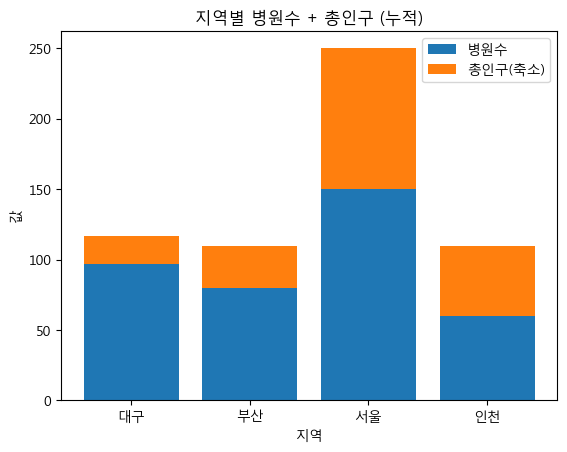

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1. 데이터 생성
# ---------------------------
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [1000000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# ---------------------------
# 2. 데이터 병합 (지역 기준)
# how='outer' → 모든 지역 포함
# ---------------------------
merged= pd.merge(df1, df2, on="지역", how="outer")

# ---------------------------
# 3. 결측치 처리
# 총인구가 없는 값 → 평균으로 채우기
# ---------------------------
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged['병원수'] = merged['병원수'].fillna(merged['병원수'].mean())
# 결과 확인
print(merged)

# ---------------------------
# 4. 한글 깨짐 방지 설정
# ---------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 첫 번째 막대 (병원수)
plt.bar(merged["지역"], merged["병원수"], label="병원수")

# 두 번째 막대 (총인구 일부 축소해서 표현)
# 단위 차이가 크기 때문에 나눠줌 (중요!)
plt.bar(
    merged["지역"],
    merged["총인구"] / 10000,
    bottom=merged["병원수"],
    label="총인구(축소)"
)

plt.title("지역별 병원수 + 총인구 (누적)")
plt.xlabel("지역")
plt.ylabel("값")

plt.legend()  # 범례 표시

plt.show()

   지역        총인구         병원수
0  대구   200000.0   96.666667
1  부산   300000.0   80.000000
2  서울  1000000.0  150.000000
3  인천   500000.0   60.000000


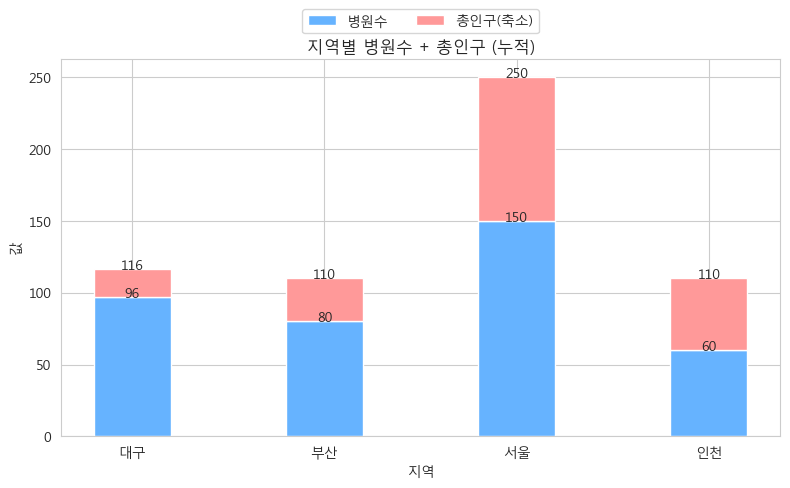

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 1. 데이터 생성
# ---------------------------
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [1000000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# ---------------------------
# 2. 데이터 병합
# ---------------------------
merged = pd.merge(df1, df2, on="지역", how="outer")

# ---------------------------
# 3. 결측치 처리
# ---------------------------
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())

print(merged)

# ---------------------------
# 4. Seaborn 스타일 + 한글
# ---------------------------
sns.set_style('whitegrid')
sns.set_palette('pastel')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------
# 5. 그래프 크기
# ---------------------------
plt.figure(figsize=(8, 5))

# ---------------------------
# 6. 색상 직접 지정
# ---------------------------
color1 = '#66b3ff'  # 병원수
color2 = '#ff9999'  # 총인구

# ---------------------------
# 7. 첫 번째 막대 (병원수)
# ---------------------------
bars1 = plt.bar(
    merged["지역"],
    merged["병원수"],
    label="병원수",
    width=0.4,
    color=color1
)

# ---------------------------
# 8. 두 번째 막대 (누적)
# ---------------------------
bars2 = plt.bar(
    merged["지역"],
    merged["총인구"] / 10000,   # 단위 축소
    bottom=merged["병원수"],    # 누적 핵심
    label="총인구(축소)",
    width=0.4,
    color=color2
)

# ---------------------------
# 9. 값 표시 (첫 번째)
# ---------------------------
for i in range(len(merged)):
    plt.text(
        i,
        merged["병원수"][i],
        int(merged["병원수"][i]),
        ha='center'
    )

# ---------------------------
# 10. 값 표시 (누적 위쪽)
# ---------------------------
for i in range(len(merged)):
    total = merged["병원수"][i] + merged["총인구"][i] / 10000
    
    plt.text(
        i,
        total,
        int(total),
        ha='center'
    )

# ---------------------------
# 11. 제목 / 라벨
# ---------------------------
plt.title("지역별 병원수 + 총인구 (누적)")
plt.xlabel("지역")
plt.ylabel("값")

# plt.legend()
# plt.legend(loc='upper left',bbox_to_anchor=(1, 1))
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=2   # 가로로 나열
)

plt.tight_layout()
plt.show()